# Retail & Marketing Analytics
Customer analytics on the UCI *Online Retail II* dataset (UK online retailer, Dec 2009 – Dec 2011).

**Pipeline:** cleaning → RFM analysis → K-Means segmentation → cohort retention → Customer Lifetime Value (CLV).

Dataset: https://archive.ics.uci.edu/dataset/502/online+retail+ii (place `online_retail_II.xlsx` in `data/`).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os; os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid'); RANDOM_STATE = 42

## 1. Load both yearly sheets

In [2]:
sheets = pd.read_excel('data/online_retail_II.xlsx', sheet_name=None)
df = pd.concat(sheets.values(), ignore_index=True)
print('Raw rows:', f'{len(df):,}')
df.head()

Raw rows: 1,067,371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Cleaning
Remove rows with no customer ID, cancelled invoices (start with 'C'), non-positive quantity/price, and exact duplicates.

In [3]:
df = df.dropna(subset=['Customer ID'])
df['Invoice'] = df['Invoice'].astype(str)
df = df[~df.Invoice.str.startswith('C')]
df = df[(df.Quantity > 0) & (df.Price > 0)]
df = df.drop_duplicates()
df = df[~df.StockCode.astype(str).isin(['POST', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE', 'ADJUST', 'D', 'C2'])]  # non-product rows
df['Customer ID'] = df['Customer ID'].astype(int)
df['Revenue'] = df.Quantity * df.Price
print(f"Clean transactions: {len(df):,} | customers: {df['Customer ID'].nunique():,} | invoices: {df.Invoice.nunique():,} | revenue: £{df.Revenue.sum():,.0f}")

Clean transactions: 776,609 | customers: 5,852 | invoices: 36,607 | revenue: £17,069,540


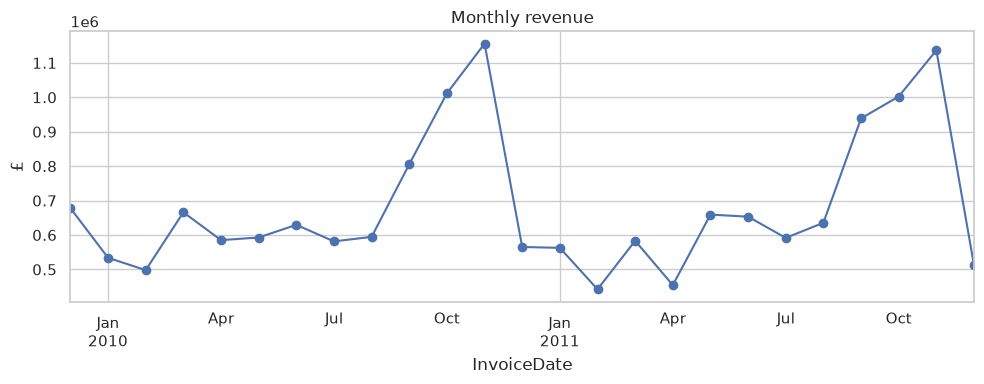

In [4]:
monthly = df.set_index('InvoiceDate').Revenue.resample('ME').sum()
monthly.plot(figsize=(10, 4), marker='o', title='Monthly revenue'); plt.ylabel('£'); plt.tight_layout(); plt.savefig('figures/monthly_revenue.png', dpi=120); plt.show()

## 3. RFM analysis

In [5]:
snapshot = df.InvoiceDate.max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg(Recency=('InvoiceDate', lambda s: (snapshot - s.max()).days),
                                    Frequency=('Invoice', 'nunique'),
                                    Monetary=('Revenue', 'sum'))
rfm['R'] = pd.qcut(rfm.Recency, 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm.Frequency.rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M'] = pd.qcut(rfm.Monetary, 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm.R + rfm.F + rfm.M
rfm.describe().round(1)

,Recency,Frequency,Monetary,R,F,M,RFM_Score
count,5852.0,5852.0,5852.0,5852.0,5852.0,5852.0,5852.0
mean,200.2,6.3,2916.9,3.0,3.0,3.0,9.0
std,208.5,12.8,14307.1,1.4,1.4,1.4,3.6
min,1.0,1.0,3.0,1.0,1.0,1.0,3.0
25%,25.0,1.0,339.6,2.0,2.0,2.0,6.0
50%,95.0,3.0,856.0,3.0,3.0,3.0,9.0
75%,379.0,7.0,2241.0,4.0,4.0,4.0,12.0
max,739.0,373.0,580987.0,5.0,5.0,5.0,15.0


## 4. K-Means customer segmentation

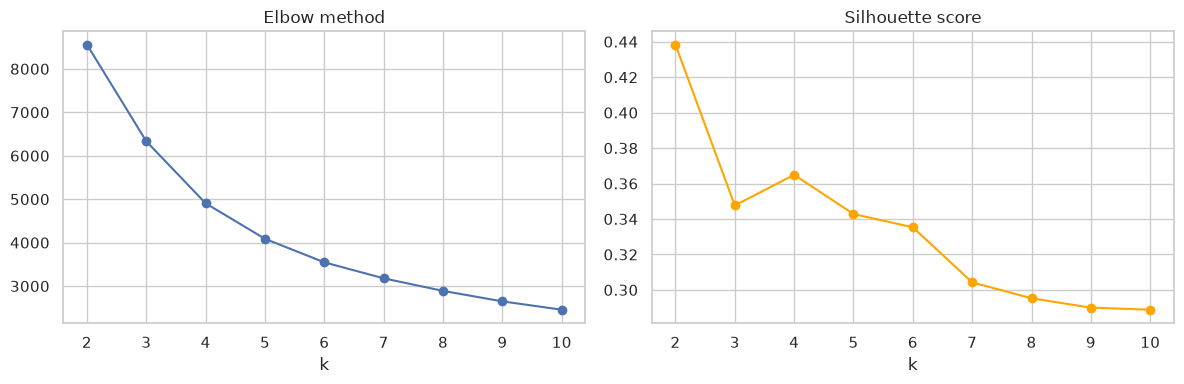

In [6]:
X = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])
Xs = StandardScaler().fit_transform(X)
ks = range(2, 11); inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xs)
    inertia.append(km.inertia_); sil.append(silhouette_score(Xs, km.labels_))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertia, marker='o'); ax[0].set_title('Elbow method'); ax[0].set_xlabel('k')
ax[1].plot(ks, sil, marker='o', color='orange'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.savefig('figures/choose_k.png', dpi=120); plt.show()

In [7]:
K = 6   # business-friendly number of segments; check the elbow/silhouette plots above
km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(Xs)
rfm['Cluster'] = km.labels_
profile = rfm.groupby('Cluster').agg(Customers=('Recency', 'size'), Recency=('Recency', 'median'),
                                     Frequency=('Frequency', 'median'), Monetary=('Monetary', 'median'),
                                     Total_Revenue=('Monetary', 'sum')).sort_values('Monetary', ascending=False)
# Name each cluster with simple business rules on its median R, F, M
def name_segment(r):
    if r.Recency <= 30 and r.Frequency >= 15: return 'Champions'
    if r.Recency <= 90 and r.Frequency >= 8:  return 'Loyal Customers'
    if r.Recency <= 30 and r.Frequency >= 4:  return 'Potential Loyalists'
    if r.Recency <= 60:                       return 'New / Promising'
    if r.Recency > 180 and r.Monetary >= 800: return 'At Risk (high value)'
    if r.Recency > 180:                       return 'Lost / Hibernating'
    return 'Needs Attention'
profile['Segment'] = profile.apply(name_segment, axis=1)
profile['Segment'] = profile.Segment + profile.groupby('Segment').cumcount().map(lambda i: '' if i == 0 else f' {i+1}')
profile['Revenue_%'] = (profile.Total_Revenue / profile.Total_Revenue.sum() * 100).round(1)
rfm['Segment'] = rfm.Cluster.map(profile.Segment)
display(profile.round(1))

,Customers,Recency,Frequency,Monetary,Total_Revenue,Segment,Revenue_%
Cluster,,,,,,,
2,471,8.0,22.0,9227.8,9276238.6,Champions,54.3
5,909,60.0,9.0,3366.0,4024805.3,Loyal Customers,23.6
0,830,14.0,5.0,1386.3,1413358.9,Potential Loyalists,8.3
3,1309,281.0,3.0,988.0,1596324.7,At Risk (high value),9.4
4,860,41.0,2.0,386.8,386698.4,New / Promising,2.3
1,1473,425.0,1.0,228.0,372114.0,Lost / Hibernating,2.2


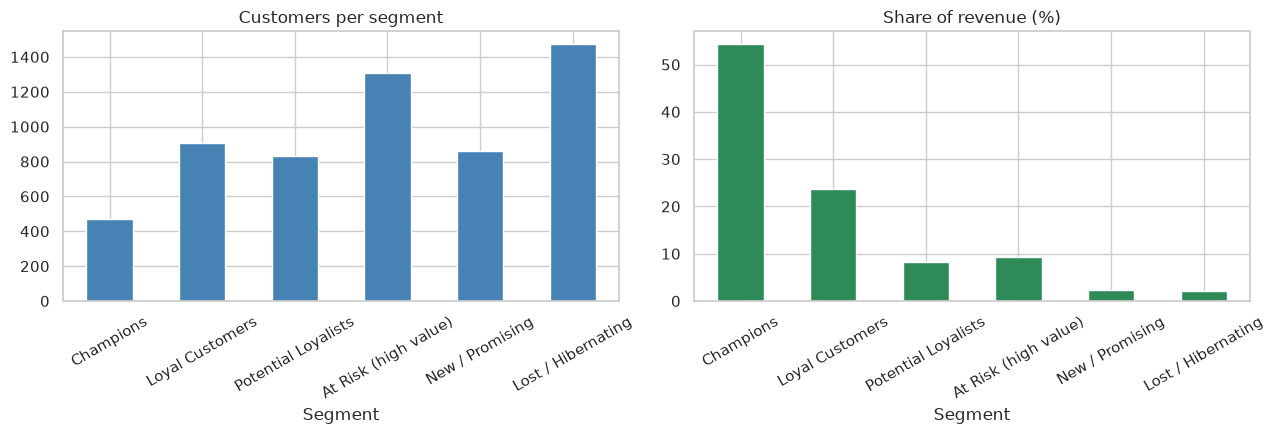

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
profile.set_index('Segment').Customers.plot(kind='bar', ax=ax[0], color='steelblue', title='Customers per segment')
profile.set_index('Segment')['Revenue_%'].plot(kind='bar', ax=ax[1], color='seagreen', title='Share of revenue (%)')
for a in ax: a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig('figures/segments.png', dpi=120); plt.show()

## 5. Cohort retention analysis

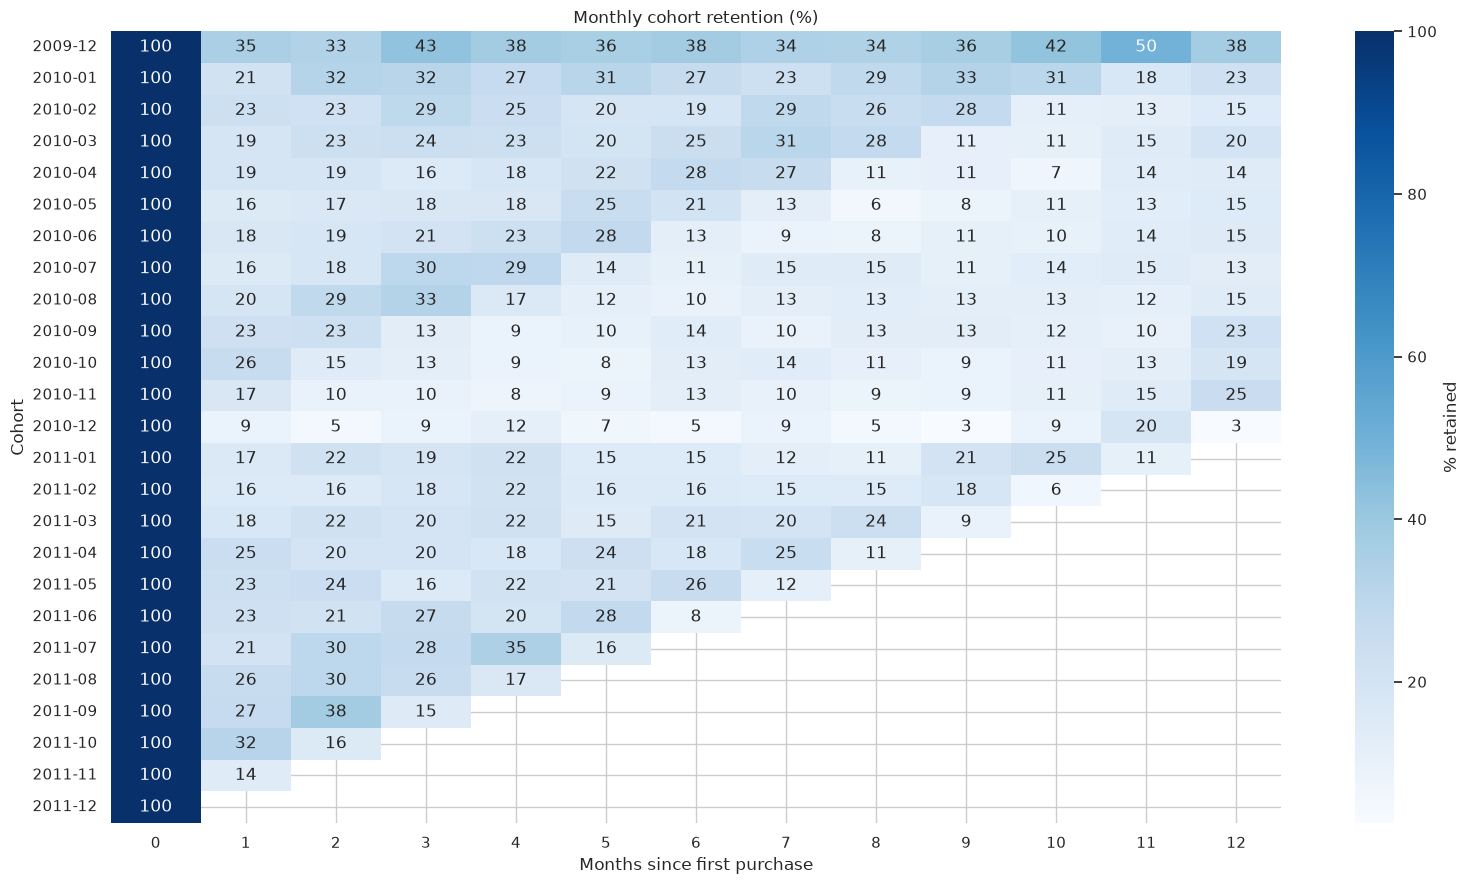

In [9]:
df['OrderMonth'] = df.InvoiceDate.dt.to_period('M')
df['Cohort'] = df.groupby('Customer ID').OrderMonth.transform('min')
df['CohortIndex'] = (df.OrderMonth - df.Cohort).apply(lambda x: x.n)
cohort = df.groupby(['Cohort', 'CohortIndex'])['Customer ID'].nunique().unstack()
retention = cohort.div(cohort[0], axis=0) * 100
plt.figure(figsize=(16, 9))
sns.heatmap(retention.iloc[:, :13], annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': '% retained'})
plt.title('Monthly cohort retention (%)'); plt.xlabel('Months since first purchase'); plt.tight_layout()
plt.savefig('figures/cohort_retention.png', dpi=120); plt.show()

In [10]:
# Customers who never came back within 2 months of their first purchase
first = df.groupby('Customer ID').InvoiceDate.min().rename('first')
d = df.join(first, on='Customer ID')
later = d[(d.InvoiceDate > d['first'].dt.normalize() + pd.Timedelta(days=1)) & (d.InvoiceDate <= d['first'] + pd.DateOffset(months=2))]
eligible = first[first <= df.InvoiceDate.max() - pd.DateOffset(months=2)].index
returned = later['Customer ID'].unique()
churn_2m = 1 - np.isin(eligible, returned).mean()
print(f'{churn_2m:.0%} of customers did not make another purchase within 2 months of their first purchase')
print(f'Average month-1 retention: {retention[1].mean():.1f}%')

65% of customers did not make another purchase within 2 months of their first purchase
Average month-1 retention: 21.0%


## 6. Customer Lifetime Value (CLV)
Simple predictive CLV:  `CLV = Avg Order Value × Purchase Frequency per year × Profit Margin × Expected Lifetime (years)`,
where expected lifetime = 1 / churn rate (churn = share of one-time buyers). Profit margin is set to 1 (revenue-based CLV); multiply by your margin to get profit CLV.

Repeat rate: 72.4% | expected lifetime: 3.62 yrs
Top 1% customers have projected CLV >= £51,215; they are 59 customers
Top 1% share of total revenue: 32.1%


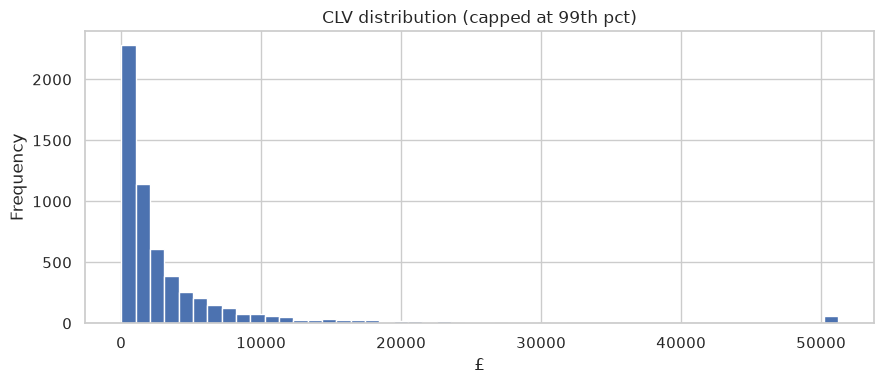

In [11]:
cust = df.groupby('Customer ID').agg(orders=('Invoice', 'nunique'), revenue=('Revenue', 'sum'),
                                     first=('InvoiceDate', 'min'), last=('InvoiceDate', 'max'))
span_years = (df.InvoiceDate.max() - df.InvoiceDate.min()).days / 365
cust['AOV'] = cust.revenue / cust.orders
cust['freq_per_year'] = cust.orders / span_years
repeat_rate = (cust.orders > 1).mean()
annual_churn = 1 - repeat_rate
lifetime_years = 1 / annual_churn
cust['CLV'] = cust.AOV * cust.freq_per_year * lifetime_years
print(f'Repeat rate: {repeat_rate:.1%} | expected lifetime: {lifetime_years:.2f} yrs')
top1 = cust.CLV.quantile(0.99)
print(f'Top 1% customers have projected CLV >= £{top1:,.0f}; they are {int((cust.CLV >= top1).sum())} customers')
print(f"Top 1% share of total revenue: {cust.loc[cust.CLV >= top1, 'revenue'].sum() / cust.revenue.sum():.1%}")
cust.CLV.clip(upper=cust.CLV.quantile(0.99)).plot(kind='hist', bins=50, figsize=(9, 4), title='CLV distribution (capped at 99th pct)')
plt.xlabel('£'); plt.tight_layout(); plt.savefig('figures/clv_distribution.png', dpi=120); plt.show()

In [12]:
summary = {'clean_transactions': len(df), 'customers': int(df['Customer ID'].nunique()), 'revenue_gbp': round(df.Revenue.sum()),
           'segments': K, 'churn_within_2_months_pct': round(churn_2m * 100, 1), 'top1pct_clv_threshold_gbp': round(top1)}
rfm.join(cust[['CLV']]).to_csv('figures/customer_segments_clv.csv')   # ready for a Power BI dashboard
pd.Series(summary).to_json('figures/summary.json'); summary

{'clean_transactions': 776609,
 'customers': 5852,
 'revenue_gbp': 17069540,
 'segments': 6,
 'churn_within_2_months_pct': np.float64(65.1),
 'top1pct_clv_threshold_gbp': 51215}

## 7. Key findings
Use the numbers printed above in your resume. `figures/customer_segments_clv.csv` can be loaded into Power BI to build a dashboard.